<a href="https://colab.research.google.com/github/sadik2g/externship-projects/blob/main/Abubakar_Ibrahim_Image_Preprocessing_and_OCR_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Success! Processed image saved as 'cleaned_document.jpg'.


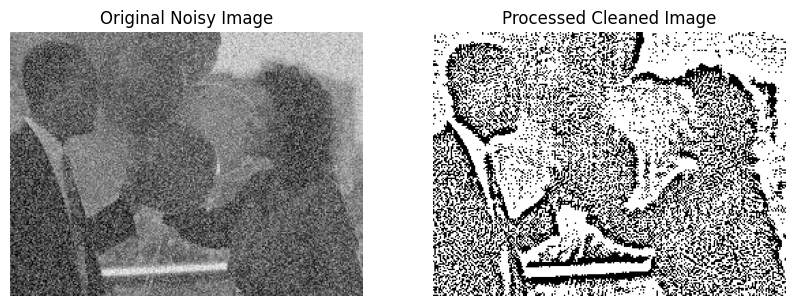

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the original noisy image in grayscale
img_path = "noisy_image_sample.jpg"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image from {img_path}. Please check the filename.")

# 2. Apply Denoising to clean up spots and speckles
denoised = cv2.fastNlMeansDenoising(img, None, h=30, templateWindowSize=7, searchWindowSize=21)

# 3. Apply Contrast Enhancement using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(denoised)

# 4. Apply Adaptive Thresholding for sharp binarization
processed_image = cv2.adaptiveThreshold(
    enhanced, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

# 5. Save the processed image
output_path = "cleaned_document.jpg"
cv2.imwrite(output_path, processed_image)
print(f"Success! Processed image saved as '{output_path}'.")

# 6. Display Original vs Processed images for comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Noisy Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(processed_image, cmap='gray')
plt.title("Processed Cleaned Image")
plt.axis('off')

plt.show()